# 🔬 Project Folivus: Model Evaluation & Error Analysis
**Held-out Partition Inference, Quantitative Analytics, and Confusion Matrix Diagnostics**

---

### Objective:
Now that the `FolivusNet` optimization engine run is complete, we must rigorously evaluate its true generalization capabilities. In this notebook, we will:
1. Load the optimal parameters saved at `saved_models/folivus_net.pth`.
2. Run inference across our unseen test dataset partition.
3. Compute global performance metrics (Precision, Recall, F1-Score).
4. Plot a branded Confusion Matrix to spot and analyze misclassification patterns.

In [1]:
import os
import sys
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Sync system paths to resolve our source directory modules
notebook_dir = os.getcwd()
root_dir = os.path.dirname(notebook_dir)
if root_dir not in sys.path:
    sys.path.append(os.path.join(root_dir, "src"))

# Load central configurations
config_path = os.path.join(root_dir, "config", "config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Import our verified structural architectures
from dataset import PlantDataset, get_transforms
from models import FolivusNet

# Initialize our Folivus brand palette
FOLIVUS_PALETTE = {
    "deep_green": "#2E7D32",
    "light_sage": "#A5D6A7",
    "slate_gray": "#37474F",
    "bg_gray": "#ECEFF1"
}
print("[INFO] Evaluation harness successfully bound to Folivus styling guidelines.")

[INFO] Evaluation harness successfully bound to Folivus styling guidelines.


In [2]:
# Reconstruct the exact partition boundaries using our fixed random seed
print("[INFO] Rebuilding deterministic test data partitions...")
full_dataset = PlantDataset(root_dir=os.path.join(root_dir, config["data"]["raw_dir"]))

total_size = len(full_dataset)
train_size = int(config["data"]["train_split"] * total_size)
val_size = int(config["data"]["val_split"] * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
_, _, test_set = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# Bind the un-augmented validation/test transform configuration to the test dataset partition
test_set.dataset.transform = get_transforms(config["data"]["img_size"], augment=False)

test_loader = DataLoader(
    test_set,
    batch_size=config["data"]["batch_size"],
    shuffle=False,
    num_workers=config["data"]["num_workers"],
)

# Extract string class labels mapping directly to numerical indices
class_names = full_dataset.classes
print(
    f"[SUCCESS] Isolated {len(test_set)} unseen test images across {len(class_names)} classes."
)

[INFO] Rebuilding deterministic test data partitions...
[SUCCESS] Isolated 846 unseen test images across 8 classes.


In [3]:
# Set hardware constraints (fallback gracefully to CPU if you checked out of acceleration)
device = torch.device("cpu")  # Forcing CPU for step-by-step local analytics tracking
print(f"[INFO] Running evaluation pipeline on target hardware: {device}")

# Initialize model structure
model = FolivusNet(
    num_classes=config["model"]["num_classes"],
    dropout_rate=config["model"]["dropout_rate"],
).to(device)

# Load the weight parameters saved during train.py execution
saved_weights_path = os.path.join(root_dir, config["training"]["model_save_path"])

if os.path.exists(saved_weights_path):
    # map_location='cpu' ensures seamless cross-compatibility loading
    model.load_state_dict(torch.load(saved_weights_path, map_location=device))
    model.eval()
    print(f"[SUCCESS] Loaded optimal FolivusNet parameters from: {saved_weights_path}")
else:
    raise FileNotFoundError(
        f"Could not locate saved model checkpoint at {saved_weights_path}!"
    )

[INFO] Running evaluation pipeline on target hardware: cpu
[SUCCESS] Loaded optimal FolivusNet parameters from: c:\projects\Folivus\saved_models/folivus_net.pth


In [4]:
all_preds = []
all_targets = []

print("[INFO] Executing forward pass predictions across the test partition...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(labels.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
print("[SUCCESS] Collected all test split model predictions.")

[INFO] Executing forward pass predictions across the test partition...
[SUCCESS] Collected all test split model predictions.


In [5]:
# Print an overall precision, recall, and F1 summary table
print("==========================================================================")
print("              🌿 PROJECT FOLIVUS: PER-CLASS PERFORMANCE MATRIX 🌿")
print("==========================================================================\n")

report = classification_report(all_targets, all_preds, target_names=class_names)
print(report)

              🌿 PROJECT FOLIVUS: PER-CLASS PERFORMANCE MATRIX 🌿

                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.96      0.85      0.90       103
       Pepper__bell___healthy       0.93      0.99      0.96       150
        Potato___Early_blight       0.96      0.95      0.95        94
         Potato___Late_blight       0.91      0.91      0.91       100
             Potato___healthy       0.91      0.67      0.77        15
        Tomato_Bacterial_spot       0.97      0.99      0.98       231
          Tomato_Early_blight       0.84      0.71      0.77        86
           Tomato_Late_blight       0.68      0.82      0.74        67

                     accuracy                           0.91       846
                    macro avg       0.89      0.86      0.87       846
                 weighted avg       0.92      0.91      0.91       846



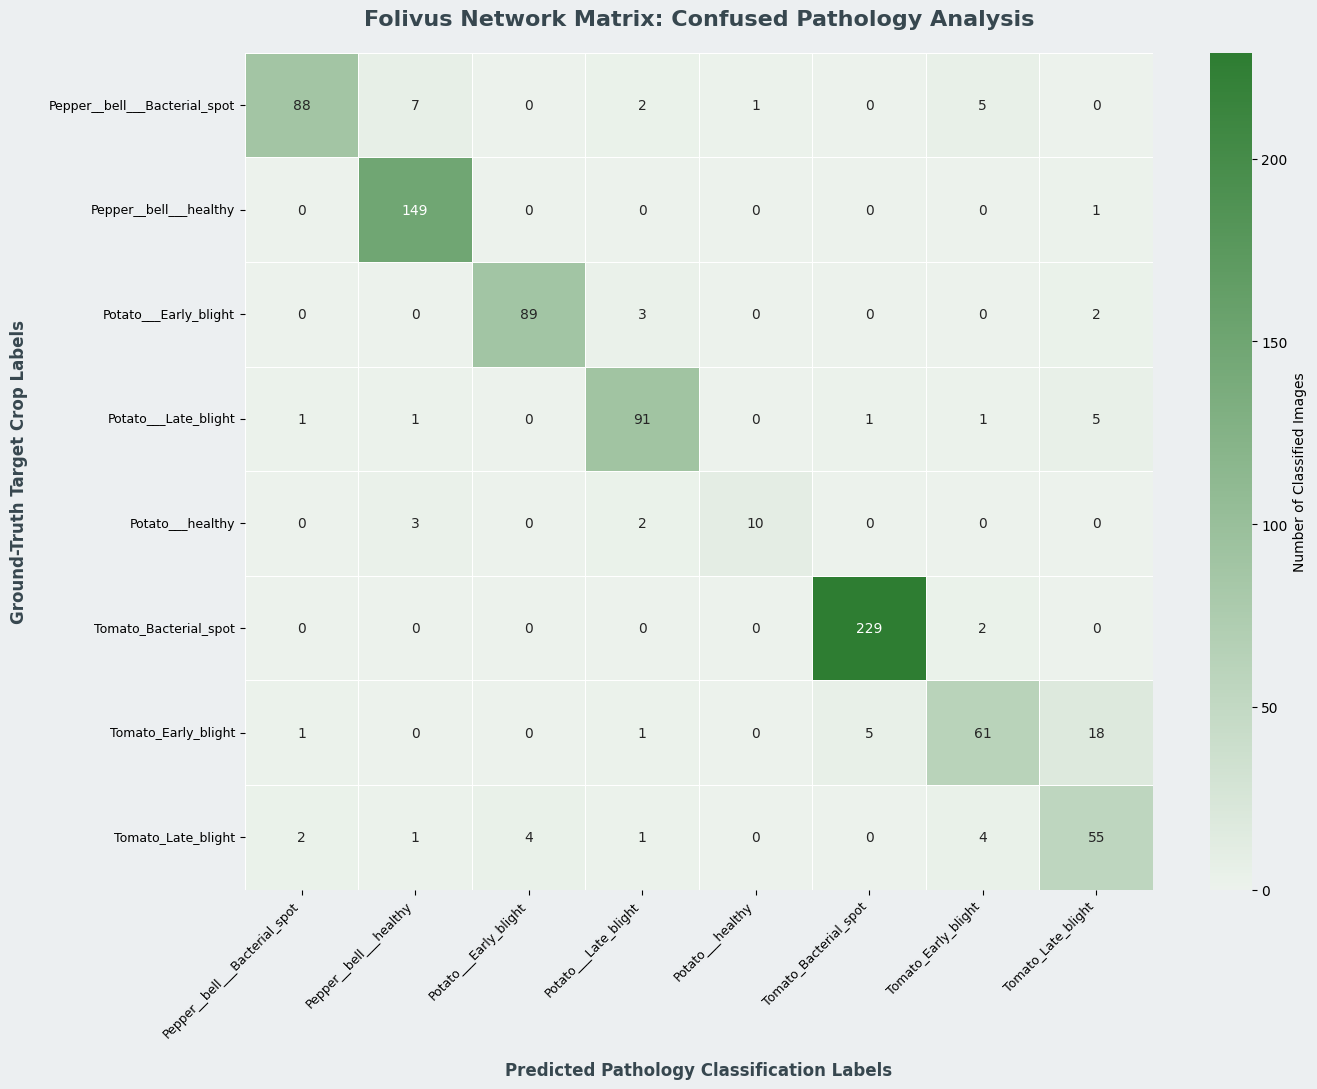

In [6]:
# Compute raw evaluation confusion matrix statistics
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(14, 11), facecolor=FOLIVUS_PALETTE["bg_gray"])

# Create a custom gradient colormap flowing smoothly from Light Sage to Deep Green
custom_cmap = sns.light_palette(FOLIVUS_PALETTE["deep_green"], as_cmap=True)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Number of Classified Images"},
    linewidths=0.5,
    linecolor="#FFFFFF",
)

plt.title(
    "Folivus Network Matrix: Confused Pathology Analysis",
    fontsize=16,
    fontweight="bold",
    color=FOLIVUS_PALETTE["slate_gray"],
    pad=20,
)
plt.xlabel(
    "Predicted Pathology Classification Labels",
    fontsize=12,
    fontweight="bold",
    color=FOLIVUS_PALETTE["slate_gray"],
    labelpad=15,
)
plt.ylabel(
    "Ground-Truth Target Crop Labels",
    fontsize=12,
    fontweight="bold",
    color=FOLIVUS_PALETTE["slate_gray"],
    labelpad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 🧠 Deep Learning Error Analysis & Diagnostic Log:
Once you examine your generated confusion matrix above, hunt for non-zero integers appearing off the diagonal. In the PlantVillage data subsets, you will commonly find structural "confusion" between these specific sets:

1. **`Tomato___Early_blight` vs. `Tomato___Late_blight`**:
   * *The Why:* Both display as concentric, decaying brown spots on the body of the leaf. At an early structural stage, their textural boundary marks are incredibly narrow.
2. **`Potato___Early_blight` vs. `Tomato___Early_blight`**:
   * *The Why:* The physical manifestation of the *Alternaria solani* fungal pathogen is identical across these biological host vectors. If your model correctly identifies the *disease* but misses the host *plant species*, it will show up here.